#### CAN-MIRGU Benign Traffic — Exploratory Data Analysis

This EDA for the normal benign CAN bus traffic, is used to establish a baseline of what normal behavior looks like compared to the attacks traffic behavior. 

Therefore the analysis gathers insights of which CAN IDs are the most representatives throughout the files, the message timing / periodicity, payload content and message sequences that will later be used for the feature engineer of the SSL pretraining model. 

- Identifying the CAN IDs used and see whether they stay consistent across files and days. 
- Message volume and overall bus traffic. 
- Analysis of the timing and regularity of messages for each CAN ID. 
- Analysis of DLC values and payload behavior. 
- Exploration of normal sequences of CAN IDs. 



In [1]:
import re 
from pathlib import Path 
from collections import Counter 
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 


In [2]:
path = Path("/Users/anita/Documents/TFM/SSL_CyberSecurity")
benign_folders = sorted(path.glob("Benign*"))
pattern = re.compile(
    r"\((.*?)\)\s+(\S+)\s+([0-9A-Fa-f]+)#([0-9A-Fa-f]*)\s*(\d*)"
)

In [3]:
# Count how many benign files are in the benign folders
benign_files = sorted(
    log_file
    for folder in benign_folders 
    for log_file in folder.rglob("*.log")
)
print(f"Benign files found: {len(benign_files)}")

Benign files found: 12


#### Benign_Day1_File2.log

For the following analysis only one file would be used since the total of the 12 files contain 106M rows. Benign Day 1 File2 is the biggest file with 10M rows which is enough for the overall analysis of the behavior of the normal traffic. 

A separate python notebook contains the cross file consistency analysis across the 12 files = CAN_IDS_FULL_ANALYSIS

In [4]:
sample_file = path / "Benign" / "Day_1" / "Benign_day1_file2.log"

rows = []
bad_rows = []

with open(sample_file, encoding="utf-8", errors="replace") as f:
    for line_number, line in enumerate(f, start=1):
        line = line.strip()

        match = pattern.fullmatch(line)

        if match is None:
            bad_rows.append({
                "line_number": line_number,
                "raw_line": line,
            })
            continue

        timestamp, interface, can_id, payload, flag = match.groups()

        rows.append({
            "timestamp": float(timestamp),
            "can_id": can_id,
            "payload": payload,
            "dlc": len(payload) // 2,
        })

benign_df = pd.DataFrame(rows)
bad_rows_df = pd.DataFrame(bad_rows)

In [5]:
benign_df.head()

,timestamp,can_id,payload,dlc
0,1.683284e+09,164,00080E06,4
1,1.683284e+09,220,F7437B0000AC0F79,8
2,1.683284e+09,381,80283D0000E1CB05,8
3,1.683284e+09,251,8B03C22B00A5B77F,8
4,1.683284e+09,2B0,0400000712,5


In [6]:
print(f"Valid rows: {len(benign_df)}")
print(f"Malformed rows: {len(bad_rows_df)}")
print("\nMissing values per column: ")
print(benign_df.isna().sum())

bad_rows_df.head()

Valid rows: 10000000
Malformed rows: 0

Missing values per column: 
timestamp    0
can_id       0
payload      0
dlc          0
dtype: int64


""


13/07/2026 
No bad rows or null values found on the dataset. 

In [7]:
benign_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000000 entries, 0 to 9999999
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   timestamp  float64
 1   can_id     object 
 2   payload    object 
 3   dlc        int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 305.2+ MB


In [8]:
benign_df["can_id"] = benign_df["can_id"].astype("category")
benign_df["dlc"] = benign_df["dlc"].astype("int8")

print("After optimisation:")
benign_df.info(memory_usage="deep")

After optimisation:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000000 entries, 0 to 9999999
Data columns (total 4 columns):
 #   Column     Dtype   
---  ------     -----   
 0   timestamp  float64 
 1   can_id     category
 2   payload    object  
 3   dlc        int8    
dtypes: category(1), float64(1), int8(1), object(1)
memory usage: 701.9 MB


In [9]:
benign_file_path = path / "benign_can_data.parquet"

benign_df.to_parquet(
    benign_file_path, 
    engine="pyarrow", 
    index = True  
)

print(f"Benign CAN data saved to {benign_file_path}")

Benign CAN data saved to /Users/anita/Documents/TFM/SSL_CyberSecurity/benign_can_data.parquet


#### General Data Analysis 

In [11]:
benign_file_path = "/Users/anita/Documents/TFM/SSL_CyberSecurity/benign_can_data.parquet"
benign_df = pd.read_parquet(benign_file_path)

print(f"Loaded {len(benign_df):,} rows from benign_can_data.parquet")

Loaded 10,000,000 rows from benign_can_data.parquet


In [12]:
print("Shape:", benign_df.shape)
print("Columns:", benign_df.columns.tolist())
print("Data types:")
print(benign_df.dtypes)

Shape: (10000000, 4)
Columns: ['timestamp', 'can_id', 'payload', 'dlc']
Data types:
timestamp     float64
can_id       category
payload        object
dlc              int8
dtype: object


In [13]:
print("Missing timestamps:", benign_df["timestamp"].isna().sum())
print("Missing CAN IDs:", benign_df["can_id"].isna().sum())
print("Missing DLC values:", benign_df["dlc"].isna().sum())

Missing timestamps: 0
Missing CAN IDs: 0
Missing DLC values: 0


In [15]:
exact_duplicates = benign_df.duplicated(
    subset=["timestamp", "can_id", "payload", "dlc"]
).sum()

print("Exact duplicate messages:", exact_duplicates)

Exact duplicate messages: 0


In [16]:
print(
    "Timestamps sorted:",
    benign_df["timestamp"].is_monotonic_increasing
)

Timestamps sorted: True


In [17]:
duplicate_timestamps = benign_df["timestamp"].duplicated().sum()

print("Repeated timestamps:", duplicate_timestamps)

Repeated timestamps: 116424


Some rows share the same timestamp, due to the time they where recorded however it does not mean that the messages themselves are duplicated. 

#### Message Volume & Traffic Rate

Per file message counts, capture duration and overall bus message rate, together with the distribution of the traffic rate across files.

How much traffic is in the saved file? How long was the data captured? How fast is the bus? 

In [24]:
def benign_saved_summary(df):
    timestamps = df["timestamp"].to_numpy()
    message_count = len(df)

    if message_count < 2:
        return None

    duration_seconds = timestamps.max() - timestamps.min()
    message_rate = message_count / duration_seconds if duration_seconds > 0 else np.nan
    dt = np.diff(timestamps)
    dlc_counts = df["dlc"].value_counts()

    return {
        "message_count": message_count,
        "duration_seconds": duration_seconds,
        "duration_minutes": duration_seconds / 60,
        "message_rate": message_rate,
        "can_ids": df["can_id"].nunique(),
    }
    
benign_summary = benign_saved_summary(benign_df)
benign_summary

{'message_count': 10000000,
 'duration_seconds': np.float64(5336.978264093399),
 'duration_minutes': np.float64(88.94963773488999),
 'message_rate': np.float64(1873.7194541860695),
 'can_ids': 56}

#### DLC Distribution 

This section examines the distribution of payload lengths in the selected benign file. DLC represents the number of payload bytes contained in each CAN message. 

In [25]:
dlc_summary = (
    benign_df["dlc"]
    .value_counts()
    .sort_index()
    .rename_axis("dlc")
    .reset_index(name="message_count")
)

dlc_summary["percentage"] = (
    dlc_summary["message_count"] / len(benign_df) * 100
)

dlc_summary 

display(dlc_summary.style.hide(axis="index"))

dlc,message_count,percentage
1,52177,0.521770
2,20285,0.202850
4,1045519,10.455190
5,521848,5.218480
6,336177,3.361770
7,104631,1.046310
8,7919363,79.193630


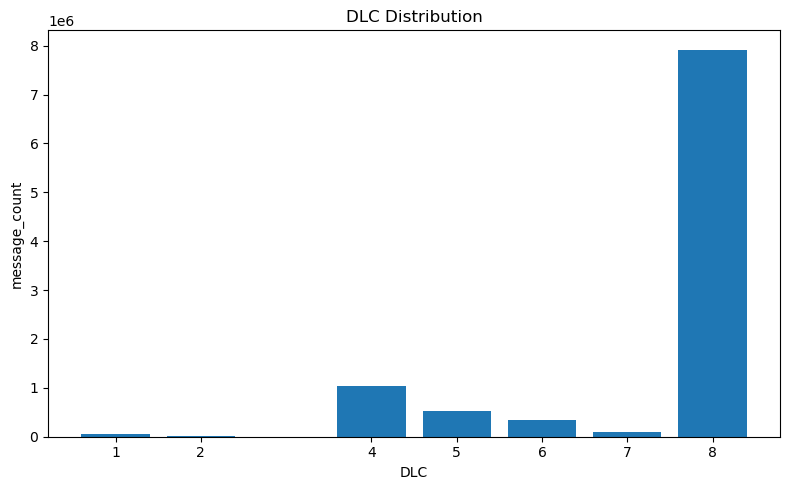

In [26]:
plt.figure(figsize=(8,5))
plt.bar(
    dlc_summary["dlc"], 
    dlc_summary["message_count"]
)

plt.xlabel("DLC")
plt.ylabel("message_count")
plt.title("DLC Distribution")
plt.xticks(dlc_summary["dlc"])
plt.tight_layout()
plt.show()

#### Global Inter Arrival Time 

Measures the time between consecutive recorded CAN messages, regardless of their CAN ID. It describes the overall spacing and activity of the CAN bus. 

In [27]:
timestamps = benign_df["timestamp"].to_numpy(copy=False)

global_dt = np.diff(timestamps)

print("Number of intervals: ", len(global_dt))
print("Zero intervals: ", np.sum(global_dt == 0))
print("Negative intervals: ", np.sum(global_dt < 0))

Number of intervals:  9999999
Zero intervals:  116424
Negative intervals:  0


In [29]:
global_summary = pd.DataFrame([{
"interval_count": len(global_dt), 
"mean_dt": np.mean(global_dt), 
"median_dt": np.median(global_dt), 
"std_dt": np.std(global_dt), 
"min_dt": np.min(global_dt), 
"max_dt": np.max(global_dt),
"q1_dt": np.percentile(global_dt, 25), 
"q3_dt": np.percentile(global_dt, 75), 
}])

global_summary["iqr_dt"] = (
    global_summary["q3_dt"] - global_summary["q1_dt"]
)

global_summary

,interval_count,mean_dt,median_dt,std_dt,min_dt,max_dt,q1_dt,q3_dt,iqr_dt
0,9999999,0.000534,0.000002,0.001065,0.0,0.010566,9.536743e-07,0.001039,0.001038


In [30]:
del global_dt

#### Per CAN ID periodicity 

For each CAN ID, the inter arrival time is calculated between consecutive appearances of that same ID. The median inter arrival time represents its typical period, while the standard deviation and IQR measure its timing variation or jitter. 

In [35]:
# Calculation of the differences separately for every CAN ID 
per_id_dt = benign_df.groupby("can_id", observed=True, sort=False)["timestamp"].diff()

In [36]:
# Excluding zero and negative intervals from the periodicity statistics 

positive_per_id = per_id_dt[per_id_dt > 0]

print(f"Total positive intervals: {len(positive_per_id)}")

# Grouping the intervals by CAN ID

dt_groups = positive_per_id.groupby(
    benign_df.loc[positive_per_id.index, "can_id"],
    observed=True,
    sort=False,
)

# Calculating the period and jitter

per_id_timing = dt_groups.agg(
    interval_count="count", 
    mean_dt="mean",
    median_dt="median", 
    std_dt="std", 
    min_dt="min", 
    max_dt="max"
)

quartiles = dt_groups.quantile([0.25, 0.75]).unstack()

quartiles.columns = ["q1_dt", "q3_dt"]

per_id_timing = per_id_timing.join(quartiles)

Total positive intervals: 9999944


In [37]:
# Calculating IQR and frequency 

per_id_timing["iqr_dt"] = (
    per_id_timing["q3_dt"] - per_id_timing["q1_dt"]
)

per_id_timing["frequency"] = (
    1 / per_id_timing["median_dt"]
)

In [41]:
message_counts = benign_df.groupby("can_id", observed=True).size()

per_id_timing["message_count"] = message_counts.reindex(per_id_timing.index)

per_id_timing["frequency_hz"] = (1 / per_id_timing["median_dt"])

per_id_timing["relative_iqr_percentage"] = (per_id_timing["iqr_dt"] 
                                            / per_id_timing["median_dt"]* 100
)

per_id_timing = per_id_timing.sort_values("median_dt")

In [42]:
timing_table = per_id_timing.reset_index()

timing_table["period_ms"] = (
    timing_table["median_dt"] * 1000
)

timing_table["iqr_jitter_ms"] = (
    timing_table["iqr_dt"] * 1000
)

timing_table["std_jitter_ms"] = (
    timing_table["std_dt"] * 1000
)

timing_table = timing_table.sort_values(
    by=["period_ms", "can_id"]
)

In [43]:
timing_display = timing_table[
    [
        "can_id",
        "message_count",
        "period_ms",
        "frequency_hz",
        "iqr_jitter_ms",
        "relative_iqr_percentage"
    ]
].copy()

display(
    timing_display.style
    .format({
        "message_count": "{:,.0f}",
        "period_ms": "{:.3f}",
        "frequency_hz": "{:.2f}",
        "iqr_jitter_ms": "{:.4f}",
        "relative_iqr_percentage": "{:.2f}"
    })
    .set_caption("Per-CAN-ID Periodicity and Jitter")
    .hide(axis="index")
)

can_id,message_count,period_ms,frequency_hz,iqr_jitter_ms,relative_iqr_percentage
372,"533,691",9.999,100.01,0.3119,3.12
371,"533,691",10.000,100.00,0.3119,3.12
153,"521,653",10.001,99.99,0.2470,2.47
160,"521,653",10.001,99.99,0.2401,2.40
164,"521,653",10.001,99.99,0.2398,2.40
220,"521,653",10.001,99.99,0.2282,2.28
251,"521,847",10.001,99.99,0.2930,2.93
2B0,"521,848",10.001,99.99,0.3331,3.33
130,"521,774",10.002,99.98,0.2990,2.99
140,"521,774",10.002,99.98,0.2909,2.91


- period_ms: normal time between appearances of the ID.
- frequency_hz: approximate messages per second.
- iqr_jitter_ms: robust absolute timing variation.
- relative_iqr_percentage: variation relative to the ID’s period.
- message_count: shows how much evidence supports the result.

In [44]:
import plotly.express as px

plot_data = timing_display[
    (timing_display["period_ms"] > 0)
    & (timing_display["relative_iqr_percentage"] > 0)
].copy()

fig = px.scatter(
    plot_data,
    x="period_ms",
    y="relative_iqr_percentage",
    size="message_count",
    hover_name="can_id",
    hover_data={
        "message_count": ":,.0f",
        "period_ms": ":.3f",
        "frequency_hz": ":.2f",
        "iqr_jitter_ms": ":.4f",
        "relative_iqr_percentage": ":.2f"
    },
    log_x=True,
    log_y=True,
    size_max=18,
    labels={
        "period_ms": "Median Period (ms)",
        "relative_iqr_percentage": "Relative IQR Jitter (%)",
        "message_count": "Message Count",
        "frequency_hz": "Frequency (Hz)",
        "iqr_jitter_ms": "IQR Jitter (ms)"
    },
    title="CAN ID Periodicity versus Relative Jitter"
)

fig.update_traces(
    marker={
        "opacity": 0.75
    }
)

fig.update_layout(
    height=650
)

fig.show()


This gives the measured benign timing baseline: 
- each point is one CAN ID 
- the horizontal position represents its typical period
- the vertical position represents its normal timing variation 

#### Payload Behavior 

Measure per CAN ID: 

- number of unique payloads
- percentage of repeated payloads 
- variability of each byte position 
- consistency of each byte position
- CAN IDs with constant versus changing payloads

This section examines the normal payload characteristics of each CAN ID. It measures the number of unique payloads, the repetition of complete payload values, and the variability of individual byte positions. 

These measurements provide a benign reference for identifying how the different attack classes alter payload content. 

In [53]:
# Payload summary 

payload_summary = (
    benign_df.groupby("can_id", observed=True)
    .agg(
        message_count=("payload", "size"),
        unique_payloads=("payload", "nunique")
    )
    .reset_index()
)

payload_summary

display(payload_summary.style.hide(axis="index"))


can_id,message_count,unique_payloads
07F,5337,1
130,521774,429592
140,521774,80847
153,521653,15
160,521653,505
164,521653,16
220,521653,514621
251,521847,451718
2B0,521848,68614
340,492680,3630


In [69]:
unique_messages = payload_summary["message_count"].unique()
print(unique_messages)

[521653 521847 521774 266836 260756 260925 533691 521848  53369  53368
 261201 260826 492680 266845   5225  45746  52240  54997 104631  26742
  26083  26721  26689  26696  10431  26685  52177  26080   5337 106738
  98536  52178   9854  52166  49268   2669   5217]


In [ ]:
payload_summary["message_count"].value_counts()

message_count
53369     7
521653    4
260756    4
26685     3
521774    2
266836    2
533691    2
260826    2
5337      2
106738    1
10431     1
52177     1
26080     1
9854      1
98536     1
52178     1
26689     1
52166     1
49268     1
2669      1
26696     1
104631    1
26721     1
26083     1
26742     1
521847    1
54997     1
52240     1
45746     1
5225      1
266845    1
492680    1
261201    1
53368     1
521848    1
260925    1
5217      1
Name: count, dtype: int64

In [68]:
unique_value_payloads = payload_summary["unique_payloads"].unique()
print(unique_value_payloads)

[514621 451718 429592 248839 232529 122011  98632  80847  72967  68614
  35352  33151  22158  10030   7173   4624   3630   2252    975    505
    205    176     86     82     39     18     16     15      7      5
      4      3      2      1]


In [70]:
payload_summary["unique_payloads"].value_counts()

unique_payloads
1         13
2          8
16         3
5          2
3          1
4          1
7          1
15         1
451718     1
18         1
39         1
82         1
86         1
176        1
205        1
505        1
975        1
514621     1
3630       1
4624       1
7173       1
10030      1
22158      1
33151      1
35352      1
68614      1
72967      1
80847      1
98632      1
122011     1
232529     1
248839     1
429592     1
2252       1
Name: count, dtype: int64

In [56]:
# How many messages repeat a previously observed payload?

payload_summary["repeated_payloads"] = (
    payload_summary["message_count"] - payload_summary["unique_payloads"]
)

payload_percentages = payload_summary[["can_id"]].copy()

payload_percentages["repeated_percentage"] = (
    payload_summary["repeated_payloads"] / payload_summary["message_count"] * 100
)

payload_percentages["unique_percentage"] = (
    payload_summary["unique_payloads"] / payload_summary["message_count"] * 100
)

payload_percentages

display(payload_percentages.style.format(precision=2).hide(axis="index"))

can_id,repeated_percentage,unique_percentage
07F,99.98,0.02
130,17.67,82.33
140,84.51,15.49
153,100.00,0.00
160,99.90,0.10
164,100.00,0.00
220,1.35,98.65
251,13.44,86.56
2B0,86.85,13.15
340,99.26,0.74


In [72]:
repeated_percentages = payload_percentages["repeated_percentage"].value_counts()
print(repeated_percentages)

repeated_percentage
99.981263    2
99.996253    2
99.993864    2
99.997970    1
99.992505    1
96.160045    1
99.996167    1
99.998083    1
99.992331    1
99.926924    1
99.843032    1
99.998126    1
99.551873    1
99.967271    1
99.980826    1
99.838858    1
99.981303    1
99.988773    1
99.962533    1
37.882252    1
99.984664    1
33.759298    1
99.670221    1
81.339713    1
91.335794    1
99.980832    1
99.989852    1
99.998083    1
17.667036    1
62.199099    1
84.505361    1
99.997125    1
99.903192    1
99.996933    1
1.348023     1
13.438613    1
86.851727    1
99.263213    1
95.848159    1
86.327856    1
12.856961    1
99.993310    1
6.744592     1
99.998082    1
97.249891    1
99.992506    1
99.992508    1
53.208747    1
99.999063    1
99.156064    1
99.999233    1
99.998985    1
99.996253    1
Name: count, dtype: int64


In [59]:
payload_summary["payload_behavior"] = np.where(payload_summary["unique_payloads"] == 1,
                                               "Constant", "Changing")


payload_summary = payload_summary.sort_values(by=["unique_payloads", "can_id"], ascending=[False, True])

display(payload_summary.style.hide(axis="index"))

can_id,message_count,unique_payloads,repeated_payloads,payload_behavior
220,521653,514621,7032,Changing
251,521847,451718,70129,Changing
130,521774,429592,92182,Changing
387,266836,248839,17997,Changing
386,266836,232529,34307,Changing
420,260756,122011,138745,Changing
381,260925,98632,162293,Changing
140,521774,80847,440927,Changing
372,533691,72967,460724,Changing
2B0,521848,68614,453234,Changing


In [61]:
payload_type_counts = payload_summary["payload_behavior"].value_counts()
print(payload_type_counts)

payload_behavior
Changing    43
Constant    13
Name: count, dtype: int64


A CAN ID with many unique payloads likely carries changing signals such as: 

- counters 
- sensor measurements 
- vehicle status values 
- timestamps 
- checksums 

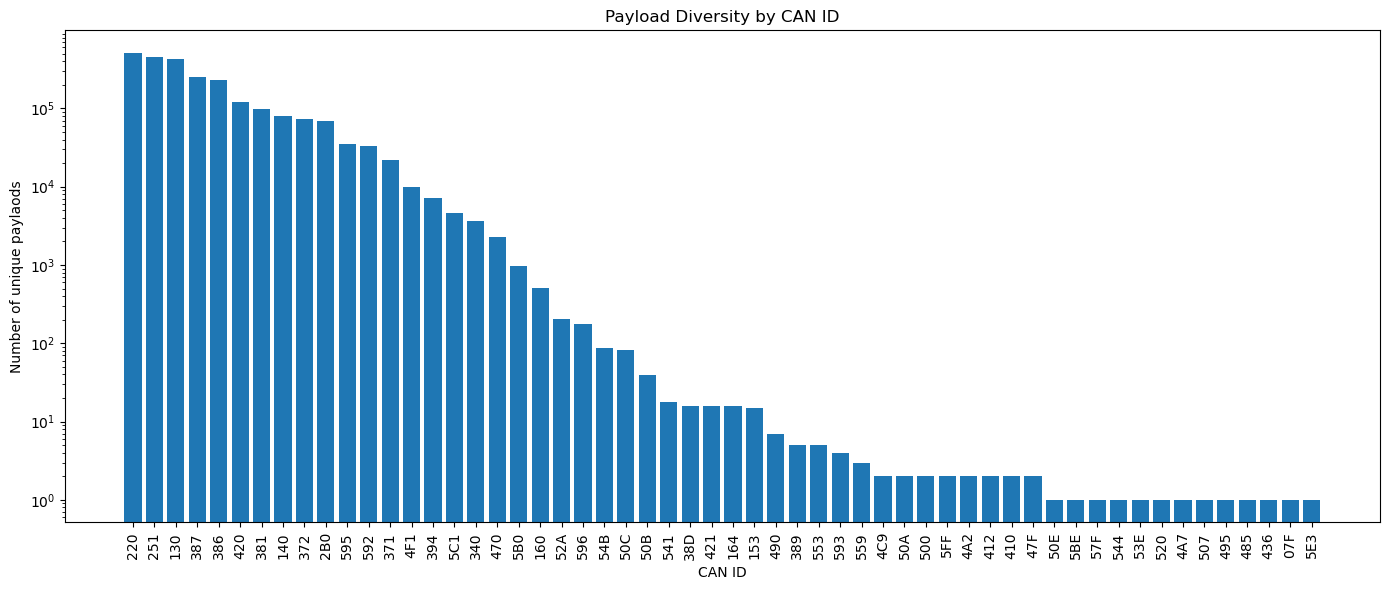

In [74]:
payload_plot = payload_summary.sort_values("unique_payloads", ascending=False)

plt.figure(figsize=(14,6))
plt.bar(
    payload_plot["can_id"].astype(str),
    payload_plot["unique_payloads"]
)
plt.yscale("log")
plt.xlabel("CAN ID")
plt.ylabel("Number of unique paylaods")
plt.title("Payload Diversity by CAN ID")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

#### Byte Position 

Payload counts tells you whether the message changes but it does not tell you which bytes change. 

Each payload is separated into its individual byte positions, for every CAN ID and byte position, the analysis measures the number of different hexadecimal values and the percentage of consecutive messages in which that byte changes. 

For each CAN ID and byte position: 
- Message count: number of messages containing that byte. 
- Unique values: number of different hexadecimal values observed. 
- Change rate percentage: how often the byte changes between consecutive messages. 
- Is constant? : Whether the byte always has the same value. 

Missing positions are ignored rather than padded with false 00 values for this EDA exploration. 

In [76]:
byte_rows = []

for can_id, group in benign_df.groupby("can_id", observed=True):

    payloads = group["payload"].astype("string")
    dlc = group["dlc"]

    for byte_position in range(8):

        start = byte_position * 2

        # Keep only messages that contain this byte
        # Byte positions start at 0.
        # A byte position exists only when DLC is at least
        # byte_position + 1.
        byte_values = payloads[
            dlc > byte_position
        ].str.slice(start, start + 2)

        if len(byte_values) == 0:
            continue

        unique_values = byte_values.nunique()

        if len(byte_values) > 1:
            change_rate = (
                byte_values.ne(byte_values.shift())
                .iloc[1:]
                .mean()
                * 100
            )
        else:
            change_rate = np.nan

        byte_rows.append({
            "can_id": can_id,
            "byte_position": byte_position,
            "message_count": len(byte_values),
            "unique_values": unique_values,
            "change_rate_percentage": change_rate,
            "is_constant": unique_values == 1
        })

byte_variability = pd.DataFrame(byte_rows)

byte_variability.head(20)

,can_id,byte_position,message_count,unique_values,change_rate_percentage,is_constant
0,07F,0,5337,1,0.000000,True
1,07F,1,5337,1,0.000000,True
2,07F,2,5337,1,0.000000,True
3,07F,3,5337,1,0.000000,True
4,07F,4,5337,1,0.000000,True
5,07F,5,5337,1,0.000000,True
6,07F,6,5337,1,0.000000,True
7,07F,7,5337,1,0.000000,True
8,130,0,521774,128,89.149879,False
9,130,1,521774,49,3.190276,False


explain output 

In [92]:
byte_id_summary = (
    byte_variability
    .groupby("can_id", observed=True)
    .agg(
        analysed_positions=(
            "byte_position",
            "count"
        ),
        constant_positions=(
            "is_constant",
            "sum"
        ),
        maximum_unique_values_in_one_byte=(
            "unique_values",
            "max"
        ),
        mean_change_rate_percentage=(
            "change_rate_percentage",
            "mean"
        )
    )
)

byte_id_summary.head()

,analysed_positions,constant_positions,maximum_unique_values_in_one_byte,mean_change_rate_percentage
can_id,,,,
07F,8,8,1,0.000000
130,8,0,256,50.498852
140,8,2,256,40.691642
153,8,6,15,25.000000
160,8,3,256,7.892402


explain output

In [97]:
byte_variability[
    byte_variability["can_id"] == "52A"
]

,can_id,byte_position,message_count,unique_values,change_rate_percentage,is_constant
267,52A,0,45746,128,11.863592,False
268,52A,1,45746,1,0.000000,True
269,52A,2,45746,1,0.000000,True
270,52A,3,45746,1,0.000000,True
271,52A,4,45746,1,0.000000,True
272,52A,5,45746,1,0.000000,True
273,52A,6,45746,80,7.375669,False
274,52A,7,45746,1,0.000000,True


explain output 

#### CAN ID sequence analysis / n grams 

- Common ID transitions (bigrams)
- Top 20 transition table 
- Common short sequences 
- Whether certain IDs usually follow other IDs 

Sequence analysis does not examine the payload, it examines the order in which CAN IDs occur. 

Normal CAN traffic often follows repeated sheduler patterns. Different attack classes may modify these patterns in different ways by inserting targeted IDs, repeating the same ID or disturbing common sequences. 

This section examines the normal ordering of CAN IDs in the selected benign recording. Bigram transisitons represent consecutive pairs of CAN IDs, while trigrams represent sequences of three consecutive IDs. 

The resulting transition patterns describe the normal message order structure that may be modified differently by the individual attack classes. 

In [ ]:
# Chronological order 
print("Timestamps_sorted: ", benign_df["timestamp"].is_monotonic_increasing)

Timestamps_sorted:  True


Sequence analysis is only useful when the messages are in the original chronological order. 

In [100]:
# Encoding the CAN IDs for bigram analysis 

ids = benign_df["can_id"].astype("category")

x = ids.cat.codes.to_numpy(
    dtype=np.int16, 
    copy=False
)

names = ids.cat.categories.to_numpy()
n = len(names)

print(f"Number of CAN IDs: {n}")


Number of CAN IDs: 56


- ids: the CAN ID column stored as categories 
- x: the same sequence represented using integer codes 
- names: converts the interger codes back into the original CAN IDs
- n: the number of unique CAN IDs 

In [ ]:
# Count the consecutive pairs 

p = (
    x[:-1].astype(np.int32) * n 
    + x[1:].astype(np.int32)
)

m = np.bincount(
    p,
    minlength=n * n
).reshape(n, n)

#### Bigram table 

In [109]:
i, j = np.nonzero(m)

bigram = pd.DataFrame({
    "from_id": names[i],
    "to_id": names[j],
    "count": m[i, j]
})

out = m.sum(axis=1)

bigram["probability"] = (
    bigram["count"].to_numpy()
    / out[i]
    * 100
)

bigram["transition"] = (
    bigram["from_id"].astype(str)
    + " → "
    + bigram["to_id"].astype(str)
)

bigram = bigram.sort_values(
    "count",
    ascending=False
).reset_index(drop=True)

bigram.head(20)


,from_id,to_id,count,probability,transition
0,130,140,521650,99.976235,130 → 140
1,164,220,512636,98.271456,164 → 220
2,153,160,509193,97.611439,153 → 160
3,160,164,508850,97.545873,160 → 164
4,371,372,380653,71.324605,371 → 372
5,251,2B0,336208,64.426546,251 → 2B0
6,420,421,225029,86.298685,420 → 421
7,386,387,224149,84.002533,386 → 387
8,389,38D,221098,84.791146,389 → 38D
9,38D,420,200328,76.825845,38D → 420


- from_id: current CAN ID 
- to_id: CAN ID that has appeared immediately afterwards
- count: the number of times that exact transition appeared 

Example: ID 371 appeared directly after ID 372 approximately 4000 times. 

- probability: Measures how often to_id follows from_id, relative to all transitions starting from from_id.  When the current ID is x, which ID usually appears next? 

In [111]:
# Top 20 bigrams 

top_bigram = bigram[
    ["transition", "count", "probability"]
].head(20)

display(
    top_bigram.style
    .format({
        "count": "{:,.0f}",
        "probability_pct": "{:.2f}"
    })
    .hide(axis="index")
)

transition,count,probability
130 → 140,"521,650",99.976235
164 → 220,"512,636",98.271456
153 → 160,"509,193",97.611439
160 → 164,"508,850",97.545873
371 → 372,"380,653",71.324605
251 → 2B0,"336,208",64.426546
420 → 421,"225,029",86.298685
386 → 387,"224,149",84.002533
389 → 38D,"221,098",84.791146
38D → 420,"200,328",76.825845


Explain table 

#### Plot the sequence 

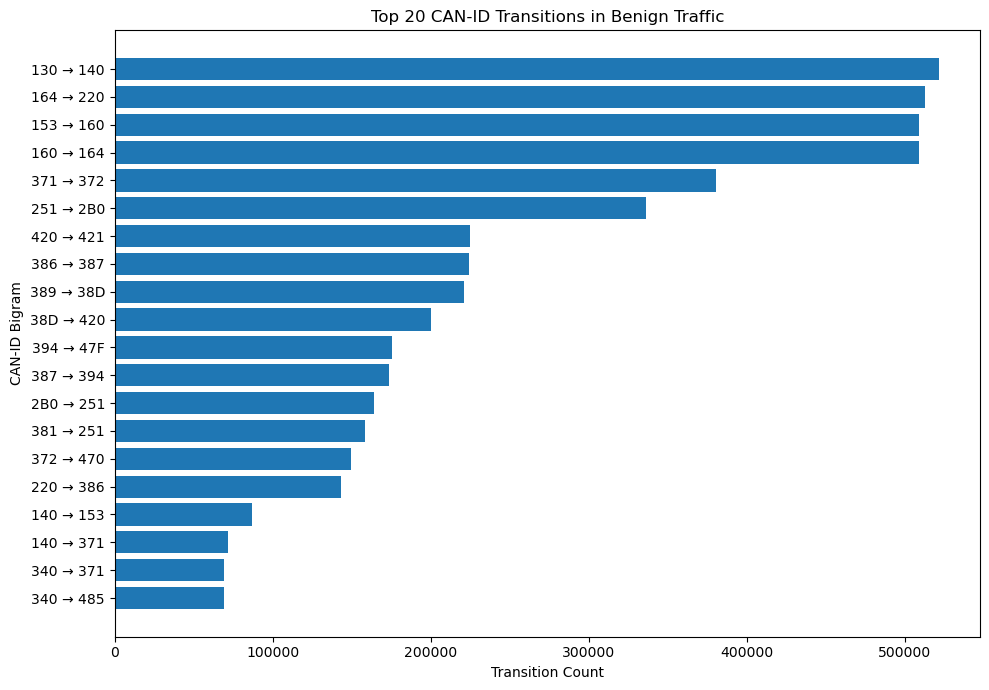

In [112]:
plot_bigram = top_bigram.sort_values("count")

plt.figure(figsize=(10, 7))

plt.barh(
    plot_bigram["transition"],
    plot_bigram["count"]
)

plt.xlabel("Transition Count")
plt.ylabel("CAN-ID Bigram")
plt.title("Top 20 CAN-ID Transitions in Benign Traffic")

plt.ticklabel_format(
    style="plain",
    axis="x"
)

plt.tight_layout()
plt.show()

Add a line plot  that goes from least frequent to most frequent transitions 

#### Self Transitions 

The CAN ID may appear twice consecutively in the recorded bus sequence. 

It can happen when the same ID is transmitted again before another ID appears, or when messages arrive in a burst. It can also happen when an ID has a much higher frequency than nearby IDs. 